# Bike Sharing Demand Prediction
## Step 2: Exploratory Data Analysis & Visualisation
**Name:** Nitin | **Roll No:** 2323008

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [12]:
bike_data = pd.read_csv("Datasets/final_dataset.csv")
print('Loaded dataset:', bike_data.shape)
bike_data.head()

Loaded dataset: (731, 11)


,season,year,month,holiday,weekday,workingday,weather,temp,humidity,windspeed,total_rentals
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600


### 1. Distribution of Daily Rentals

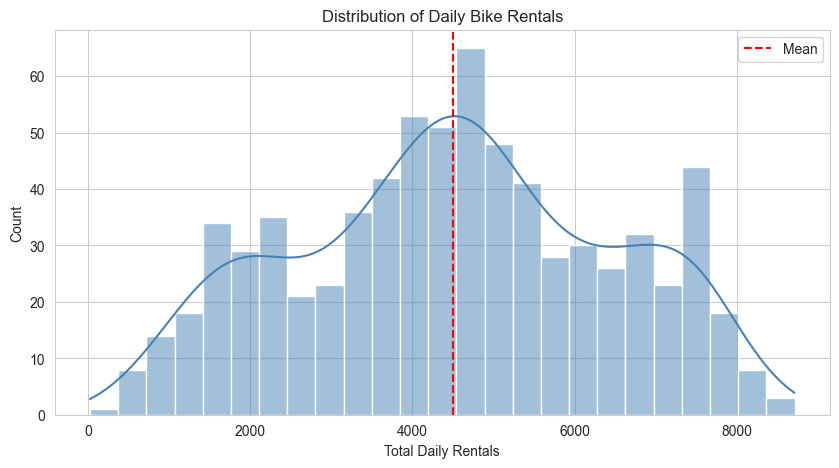

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(bike_data['total_rentals'], bins=25, kde=True, color='steelblue')
plt.xlabel('Total Daily Rentals')
plt.ylabel('Count')
plt.title('Distribution of Daily Bike Rentals')
plt.axvline(bike_data['total_rentals'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()
# Insight: Rentals are roughly bell-shaped; mean is around 4500/day

### 2. Effect of Temperature on Rentals

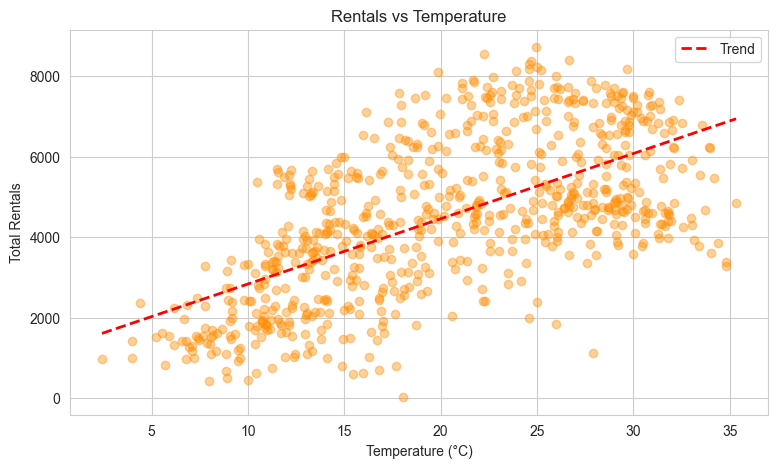

In [6]:
# Convert normalized temp back to Celsius (temp = t/41)
actual_temp = bike_data['temp'] * 41
plt.figure(figsize=(9, 5))
plt.scatter(actual_temp, bike_data['total_rentals'], alpha=0.4, color='darkorange')
# Trend line
z = np.polyfit(actual_temp, bike_data['total_rentals'], 1)
p = np.poly1d(z)
plt.plot(sorted(actual_temp), p(sorted(actual_temp)), 'r--', linewidth=2, label='Trend')
plt.xlabel('Temperature (°C)')
plt.ylabel('Total Rentals')
plt.title('Rentals vs Temperature')
plt.legend()
plt.show()
# Insight: Strong positive correlation — warmer = more rentals

### 3. Seasonal Rental Patterns

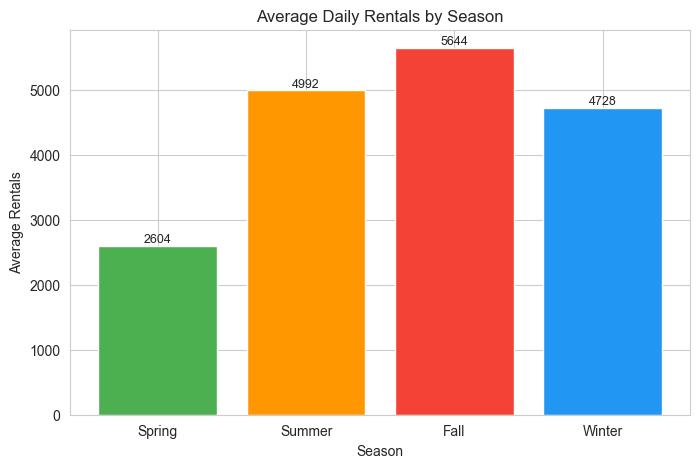

In [7]:
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
season_avg = bike_data.groupby('season')['total_rentals'].mean()
season_avg.index = season_avg.index.map(season_labels)

plt.figure(figsize=(8, 5))
bars = plt.bar(season_avg.index, season_avg.values, color=['#4CAF50','#FF9800','#F44336','#2196F3'])
plt.xlabel('Season')
plt.ylabel('Average Rentals')
plt.title('Average Daily Rentals by Season')
for bar, val in zip(bars, season_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{int(val)}', ha='center', fontsize=9)
plt.show()
# Insight: Fall has highest demand; Spring lowest

### 4. Working Day vs Holiday Rentals

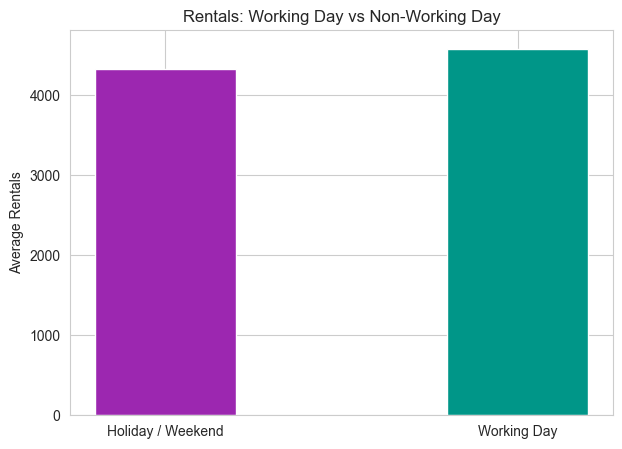

In [8]:
day_type_avg = bike_data.groupby('workingday')['total_rentals'].mean()
labels = ['Holiday / Weekend', 'Working Day']
plt.figure(figsize=(7, 5))
plt.bar(labels, day_type_avg.values, color=['#9C27B0', '#009688'], width=0.4)
plt.ylabel('Average Rentals')
plt.title('Rentals: Working Day vs Non-Working Day')
plt.show()
# Insight: Slightly higher on working days due to commuters

### 5. Weather Condition Impact

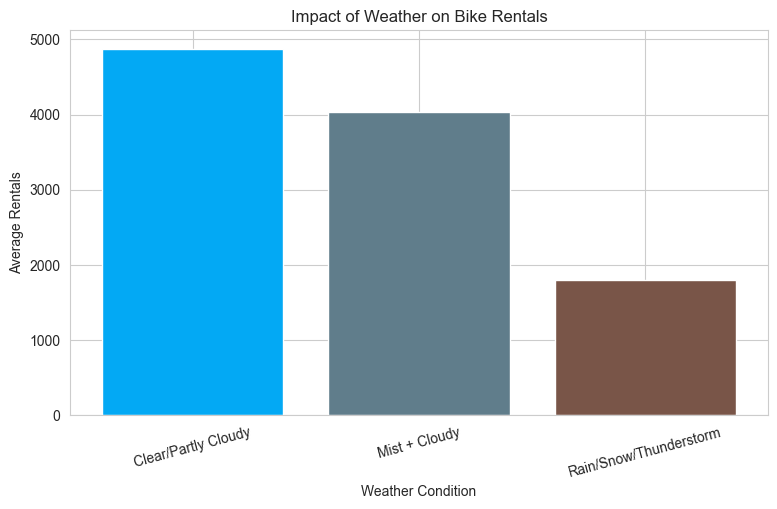

In [9]:
weather_labels = {
    1: 'Clear/Partly Cloudy',
    2: 'Mist + Cloudy',
    3: 'Rain/Snow/Thunderstorm'
}
weather_avg = bike_data.groupby('weather')['total_rentals'].mean()
weather_avg.index = weather_avg.index.map(weather_labels)

plt.figure(figsize=(9, 5))
plt.bar(weather_avg.index, weather_avg.values, color=['#03A9F4','#607D8B','#795548'])
plt.xlabel('Weather Condition')
plt.ylabel('Average Rentals')
plt.title('Impact of Weather on Bike Rentals')
plt.xticks(rotation=15)
plt.show()
# Insight: Bad weather drastically reduces demand

### 6. Monthly Rental Trend

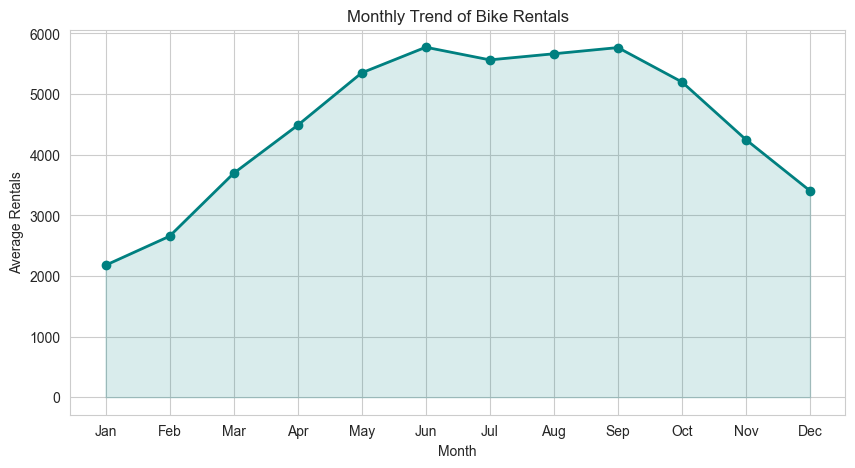

In [10]:
month_avg = bike_data.groupby('month')['total_rentals'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 5))
plt.plot(range(1,13), month_avg.values, marker='o', color='teal', linewidth=2)
plt.xticks(range(1,13), month_names)
plt.xlabel('Month')
plt.ylabel('Average Rentals')
plt.title('Monthly Trend of Bike Rentals')
plt.fill_between(range(1,13), month_avg.values, alpha=0.15, color='teal')
plt.show()
# Insight: Peak in summer/fall months (June-October)

### 7. Humidity & Windspeed Effect

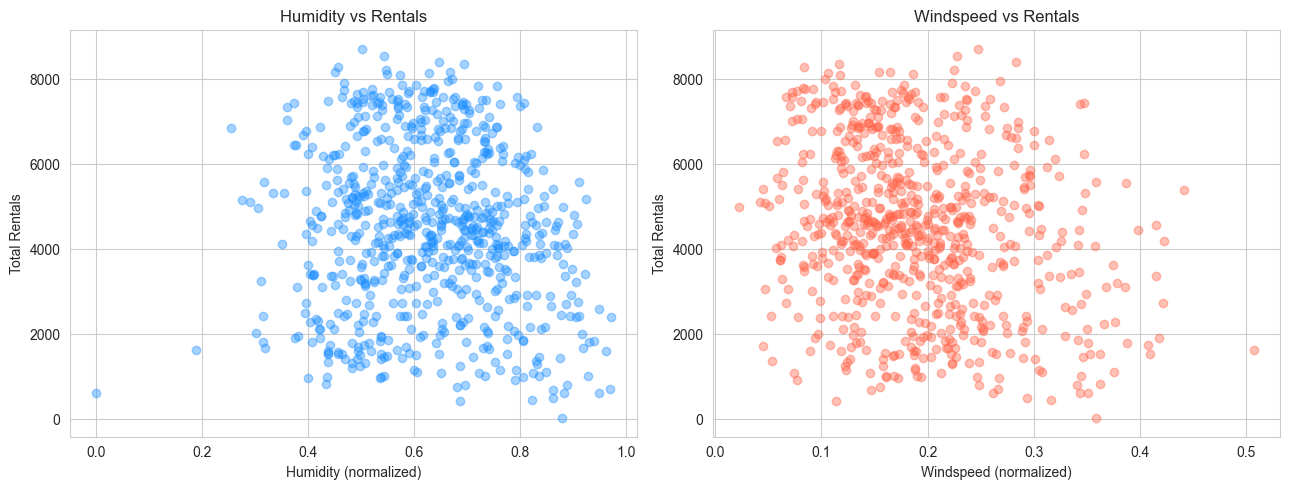

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(bike_data['humidity'], bike_data['total_rentals'], alpha=0.4, color='dodgerblue')
axes[0].set_xlabel('Humidity (normalized)')
axes[0].set_ylabel('Total Rentals')
axes[0].set_title('Humidity vs Rentals')

axes[1].scatter(bike_data['windspeed'], bike_data['total_rentals'], alpha=0.4, color='tomato')
axes[1].set_xlabel('Windspeed (normalized)')
axes[1].set_ylabel('Total Rentals')
axes[1].set_title('Windspeed vs Rentals')

plt.tight_layout()
plt.show()
# Insight: High humidity & high windspeed both reduce rentals